In [2]:
!pip install torch numpy seaborn tqdm sacrebleu

  Using cached sacrebleu-2.5.1-py3-none-any.whl.metadata (51 kB)
  Using cached portalocker-3.2.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached lxml-6.0.2-cp310-cp310-manylinux_2_26_x86_64.manylinux_2_28_x86_64.whl.metadata (3.6 kB)
Using cached sacrebleu-2.5.1-py3-none-any.whl (104 kB)
Using cached lxml-6.0.2-cp310-cp310-manylinux_2_26_x86_64.manylinux_2_28_x86_64.whl (5.3 MB)
Using cached portalocker-3.2.0-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [sacrebleu]/3 [sacrebleu]


In [3]:
# Cell 1: Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import random
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# For BLEU score calculation
try:
    from sacrebleu.metrics import BLEU
    bleu_available = True
    print("✓ BLEU score calculation available (sacrebleu installed)")
except ImportError:
    bleu_available = False
    print("⚠ sacrebleu not installed. Install with: pip install sacrebleu")
    print("  BLEU scores will be skipped in evaluation.")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Text processing imports
import unicodedata
import re

TEACHER_FORCING_RATIO = 0.5
MAX_LENGTH = 10  # We'll filter sentences longer than this to speed up training
SOS_TOKEN = 0    # Start of Sentence
EOS_TOKEN = 1    # End of Sentence
PAD_TOKEN = 2    # Padding

✓ BLEU score calculation available (sacrebleu installed)
Using device: cpu


In [2]:
# # Cell 2: Create a toy dataset with simple parallel sentences
# # This simulates English to Swahili-like translation patterns

# # Toy parallel corpus (English -> Target Language)
# parallel_sentences = [
#     # Simple greetings
#     ("hello", "jambo"),
#     ("good morning", "habari ya asubuhi"),
#     ("good evening", "habari ya jioni"),
#     ("how are you", "habari yako"),
#     ("thank you", "asante"),
#     ("welcome", "karibu"),

#     # Simple phrases
#     ("i am fine", "niko sawa"),
#     ("what is your name", "jina lako nani"),
#     ("my name is john", "jina langu ni john"),
#     ("where are you from", "unatoka wapi"),
#     ("i am from kenya", "natoka kenya"),
#     ("i am from tanzania", "natoka tanzania"),

#     # Numbers and basic concepts
#     ("one two three", "moja mbili tatu"),
#     ("i love you", "nakupenda"),
#     ("good night", "usiku mwema"),
#     ("see you tomorrow", "tutaonana kesho"),
#     ("please help me", "tafadhali nisaidie"),
#     ("yes", "ndiyo"),
#     ("no", "hapana"),

#     # Food and daily life
#     ("i want water", "nataka maji"),
#     ("i want food", "nataka chakula"),
#     ("where is the market", "soko liko wapi"),
#     ("how much", "bei gani"),
#     ("very good", "nzuri sana"),

#     # Extended phrases for variety
#     ("the book is red", "kitabu ni nyekundu"),
#     ("the car is fast", "gari ni kasi"),
#     ("i go to school", "naenda shule"),
#     ("she is a teacher", "yeye ni mwalimu"),
#     ("we are learning", "tunajifunza"),
# ]

# # Augment dataset with repetitions and variations
# augmented_data = []
# for _ in range(20):  # Repeat dataset for more training examples
#     for src, tgt in parallel_sentences:
#         augmented_data.append((src, tgt))

# # Shuffle the augmented data
# random.shuffle(augmented_data)

# print(f"Total number of sentence pairs: {len(augmented_data)}")
# print("\nSample translations:")
# for i in range(5):
#     src, tgt = augmented_data[i]
#     print(f"  {src:30} -> {tgt}")



In [4]:
# Cell 2: Load and prepare eng-fra dataset
# This cell downloads the English-French parallel corpus and prepares it for training

# Helper to download and unzip the data
# !wget -O eng-fra.zip https://download.pytorch.org/tutorial/data.zip
# !unzip -o eng-fra.zip
# !mv data/eng-fra.txt .

# Vocabulary class to map words to indices
class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {"<SOS>": SOS_TOKEN, "<EOS>": EOS_TOKEN, "<PAD>": PAD_TOKEN}
        self.word2count = {}
        self.index2word = {SOS_TOKEN: "<SOS>", EOS_TOKEN: "<EOS>", PAD_TOKEN: "<PAD>"}
        self.n_words = 3  # Count SOS, EOS, PAD

    def add_sentence(self, sentence):
        for word in sentence.split(' '):
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

# Helper functions for text normalization
def unicode_to_ascii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

def normalize_string(s):
    s = unicode_to_ascii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    return s

# Read and process the data
def read_langs(lang1, lang2, reverse=False):
    print("Reading lines...")
    lines = open('eng-fra.txt', encoding='utf-8').read().strip().split('\n')
    pairs = [[normalize_string(s) for s in l.split('\t')] for l in lines]

    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)

    return input_lang, output_lang, pairs

# Filter pairs to our MAX_LENGTH constraint
def filter_pair(p):
    return len(p[0].split(' ')) < MAX_LENGTH and \
        len(p[1].split(' ')) < MAX_LENGTH

def filter_pairs(pairs):
    return [p for p in pairs if filter_pair(p)]

def prepare_data(lang1, lang2, reverse=False):
    input_lang, output_lang, pairs = read_langs(lang1, lang2, reverse)
    print(f"Read {len(pairs)} sentence pairs")
    pairs = filter_pairs(pairs)
    print(f"Trimmed to {len(pairs)} sentence pairs (max length {MAX_LENGTH})")
    print("Counting words...")
    for pair in pairs:
        input_lang.add_sentence(pair[0])
        output_lang.add_sentence(pair[1])
    print("Counted words:")
    print(f"{input_lang.name}: {input_lang.n_words}")
    print(f"{output_lang.name}: {output_lang.n_words}")
    return input_lang, output_lang, pairs

# ⚠️ IMPORTANT: Language Direction Configuration
# reverse=True means: French (fra) → English (eng)
# reverse=False would mean: English (eng) → French (fra)
# 
# With reverse=True:
#   - input_lang = French (source language)
#   - output_lang = English (target language)
#   - Model translates FROM French TO English

print("=" * 70)
print("LOADING DATASET: French → English Translation")
print("=" * 70)

input_lang, output_lang, augmented_data = prepare_data('eng', 'fra', True)

print(f"\n✓ Dataset loaded successfully!")
print(f"  Translation direction: {input_lang.name} → {output_lang.name}")

LOADING DATASET: French → English Translation
Reading lines...
Read 135842 sentence pairs
Trimmed to 95170 sentence pairs (max length 10)
Counting words...
Counted words:
fra: 16814
eng: 10026

✓ Dataset loaded successfully!
  Translation direction: fra → eng


In [5]:
# Cell 3: Vocabulary building and text processing

class Vocabulary:
    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}
        self.word_count = Counter()

        # Special tokens
        self.pad_token = '<PAD>'
        self.sos_token = '<SOS>'
        self.eos_token = '<EOS>'
        self.unk_token = '<UNK>'

        # Add special tokens
        for token in [self.pad_token, self.sos_token, self.eos_token, self.unk_token]:
            self.add_word(token)

    def add_word(self, word):
        if word not in self.word2idx:
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word
        self.word_count[word] += 1

    def add_sentence(self, sentence):
        for word in sentence.split():
            self.add_word(word)

    def __len__(self):
        return len(self.word2idx)

    def encode(self, sentence):
        tokens = sentence.split()
        indices = [self.word2idx[self.sos_token]]
        for token in tokens:
            indices.append(self.word2idx.get(token, self.word2idx[self.unk_token]))
        indices.append(self.word2idx[self.eos_token])
        return indices

    def decode(self, indices):
        words = []
        for idx in indices:
            if idx == self.word2idx[self.eos_token]:
                break
            if idx not in [self.word2idx[self.pad_token], self.word2idx[self.sos_token]]:
                words.append(self.idx2word[idx])
        return ' '.join(words)

# Build vocabularies
src_vocab = Vocabulary()
tgt_vocab = Vocabulary()

for src, tgt in augmented_data:
    src_vocab.add_sentence(src)
    tgt_vocab.add_sentence(tgt)

print(f"Source vocabulary size: {len(src_vocab)}")
print(f"Target vocabulary size: {len(tgt_vocab)}")
print(f"\nSource vocabulary sample: {list(src_vocab.word2idx.keys())[:10]}")
print(f"Target vocabulary sample: {list(tgt_vocab.word2idx.keys())[:10]}")

Source vocabulary size: 16814
Target vocabulary size: 10026

Source vocabulary sample: ['<PAD>', '<SOS>', '<EOS>', '<UNK>', 'va', '!', 'cours', 'courez', 'ca', 'alors']
Target vocabulary sample: ['<PAD>', '<SOS>', '<EOS>', '<UNK>', 'go', '.', 'run', '!', 'wow', 'fire']


In [6]:
# Cell 4: Dataset class for PyTorch

class TranslationDataset(Dataset):
    def __init__(self, data, src_vocab, tgt_vocab):
        self.data = data
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src, tgt = self.data[idx]
        src_encoded = torch.tensor(self.src_vocab.encode(src), dtype=torch.long)
        tgt_encoded = torch.tensor(self.tgt_vocab.encode(tgt), dtype=torch.long)
        return src_encoded, tgt_encoded

def collate_fn(batch):
    """Custom collate function to pad sequences in a batch"""
    src_batch, tgt_batch = zip(*batch)
    src_batch = pad_sequence(src_batch, batch_first=True, padding_value=0)
    tgt_batch = pad_sequence(tgt_batch, batch_first=True, padding_value=0)
    return src_batch, tgt_batch

# Split data into train/validation/test sets (70/15/15 split)
# This ensures we have a held-out test set that's never seen during training
total_size = len(augmented_data)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size  # Remaining data

train_data = augmented_data[:train_size]
val_data = augmented_data[train_size:train_size + val_size]
test_data = augmented_data[train_size + val_size:]

# Create datasets and dataloaders
train_dataset = TranslationDataset(train_data, src_vocab, tgt_vocab)
val_dataset = TranslationDataset(val_data, src_vocab, tgt_vocab)
test_dataset = TranslationDataset(test_data, src_vocab, tgt_vocab)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

print("=" * 70)
print("DATASET SPLITS")
print("=" * 70)
print(f"Training samples:   {len(train_dataset):,} ({train_size/total_size*100:.1f}%)")
print(f"Validation samples: {len(val_dataset):,} ({val_size/total_size*100:.1f}%)")
print(f"Test samples:       {len(test_dataset):,} ({test_size/total_size*100:.1f}%)")
print(f"Total samples:      {total_size:,}")
print(f"Batch size:         {batch_size}")
print("=" * 70)

DATASET SPLITS
Training samples:   66,619 (70.0%)
Validation samples: 14,275 (15.0%)
Test samples:       14,276 (15.0%)
Total samples:      95,170
Batch size:         32


In [7]:
# Cell 4: Dataset class for PyTorch

class TranslationDataset(Dataset):
    def __init__(self, data, src_vocab, tgt_vocab):
        self.data = data
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src, tgt = self.data[idx]
        src_encoded = torch.tensor(self.src_vocab.encode(src), dtype=torch.long)
        tgt_encoded = torch.tensor(self.tgt_vocab.encode(tgt), dtype=torch.long)
        return src_encoded, tgt_encoded

def collate_fn(batch):
    """Custom collate function to pad sequences in a batch"""
    src_batch, tgt_batch = zip(*batch)
    src_batch = pad_sequence(src_batch, batch_first=True, padding_value=0)
    tgt_batch = pad_sequence(tgt_batch, batch_first=True, padding_value=0)
    return src_batch, tgt_batch

# Split data into train and validation sets
train_size = int(0.8 * len(augmented_data))
train_data = augmented_data[:train_size]
val_data = augmented_data[train_size:]

# Create datasets and dataloaders
train_dataset = TranslationDataset(train_data, src_vocab, tgt_vocab)
val_dataset = TranslationDataset(val_data, src_vocab, tgt_vocab)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Batch size: {batch_size}")

Training samples: 76136
Validation samples: 19034
Batch size: 32


In [8]:
# Cell 5: Vanilla RNN Encoder

class VanillaRNNEncoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, dropout_p=0.1):
        super(VanillaRNNEncoder, self).__init__()

        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.dropout = nn.Dropout(dropout_p)

        # Vanilla RNN cell - implementing from scratch
        self.rnn_cell = nn.RNNCell(embed_size, hidden_size)

    def forward(self, x, hidden=None):
        """
        Args:
            x: Input tensor of shape (batch_size, seq_len)
            hidden: Initial hidden state
        Returns:
            outputs: All hidden states (batch_size, seq_len, hidden_size)
            hidden: Final hidden state (batch_size, hidden_size)
        """
        batch_size = x.size(0)
        seq_len = x.size(1)

        # Initialize hidden state if not provided
        if hidden is None:
            hidden = torch.zeros(batch_size, self.hidden_size).to(x.device)

        # Embedding
        embedded = self.embedding(x)  # (batch_size, seq_len, embed_size)
        embedded = self.dropout(embedded)

        outputs = []

        # Process sequence step by step (vanilla RNN style)
        for t in range(seq_len):
            # RNN cell computation
            hidden = self.rnn_cell(embedded[:, t, :], hidden)
            hidden = torch.tanh(hidden)  # Apply activation
            outputs.append(hidden.unsqueeze(1))

        outputs = torch.cat(outputs, dim=1)  # (batch_size, seq_len, hidden_size)

        return outputs, hidden

# Test encoder
test_encoder = VanillaRNNEncoder(len(src_vocab), 128, 256)
test_input = torch.randint(0, len(src_vocab), (2, 10))  # batch_size=2, seq_len=10
test_outputs, test_hidden = test_encoder(test_input)
print(f"Encoder outputs shape: {test_outputs.shape}")
print(f"Encoder final hidden shape: {test_hidden.shape}")

Encoder outputs shape: torch.Size([2, 10, 256])
Encoder final hidden shape: torch.Size([2, 256])


In [10]:
# Cell 6: Vanilla RNN Decoder

class VanillaRNNDecoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, dropout_p=0.1):
        super(VanillaRNNDecoder, self).__init__()

        self.vocab_size = vocab_size
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.dropout = nn.Dropout(dropout_p)

        # Vanilla RNN cell
        self.rnn_cell = nn.RNNCell(embed_size, hidden_size)

        # Output projection layer
        self.output_projection = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, encoder_hidden, encoder_outputs=None):
        """
        Args:
            x: Target input tensor (batch_size, seq_len)
            encoder_hidden: Final hidden state from encoder
            encoder_outputs: Not used in vanilla RNN (kept for compatibility)
        Returns:
            outputs: Predictions (batch_size, seq_len, vocab_size)
        """
        batch_size = x.size(0)
        seq_len = x.size(1)

        # Initialize decoder hidden state with encoder's final hidden state
        hidden = encoder_hidden

        # Embedding
        embedded = self.embedding(x)  # (batch_size, seq_len, embed_size)
        embedded = self.dropout(embedded)

        outputs = []

        # Decode step by step
        for t in range(seq_len):
            # RNN cell computation
            hidden = self.rnn_cell(embedded[:, t, :], hidden)
            hidden = torch.tanh(hidden)

            # Project to vocabulary size
            output = self.output_projection(hidden)
            outputs.append(output.unsqueeze(1))

        outputs = torch.cat(outputs, dim=1)  # (batch_size, seq_len, vocab_size)

        return outputs

# Test decoder
test_decoder = VanillaRNNDecoder(len(tgt_vocab), 128, 256)
test_target = torch.randint(0, len(tgt_vocab), (2, 8))  # batch_size=2, seq_len=8
test_decoder_outputs = test_decoder(test_target, test_hidden)
print(f"Decoder outputs shape: {test_decoder_outputs.shape}")

Decoder outputs shape: torch.Size([2, 8, 10026])


In [11]:
# Cell 7: Complete Vanilla RNN Seq2Seq Model

class VanillaSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super(VanillaSeq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        """
        Args:
            src: Source sequences (batch_size, src_seq_len)
            tgt: Target sequences (batch_size, tgt_seq_len)
        Returns:
            outputs: Predictions (batch_size, tgt_seq_len, vocab_size)
        """
        # Encode source sequence
        encoder_outputs, encoder_hidden = self.encoder(src)

        # Decode to target sequence
        outputs = self.decoder(tgt, encoder_hidden)

        return outputs

    def translate(self, src, max_length=50):
        """Translate a source sentence (inference mode)"""
        self.eval()
        with torch.no_grad():
            # Encode source
            encoder_outputs, encoder_hidden = self.encoder(src)

            batch_size = src.size(0)
            device = src.device

            # Start with SOS token
            decoder_input = torch.tensor([[1]]).to(device)  # SOS token index
            hidden = encoder_hidden

            translated = []

            for _ in range(max_length):
                # Decode one step
                embedded = self.decoder.embedding(decoder_input)
                hidden = self.decoder.rnn_cell(embedded.squeeze(1), hidden)
                hidden = torch.tanh(hidden)
                output = self.decoder.output_projection(hidden)

                # Get predicted word
                predicted = output.argmax(dim=-1)
                translated.append(predicted.item())

                # Stop if EOS token is predicted
                if predicted.item() == 2:  # EOS token index
                    break

                # Use predicted word as next input
                decoder_input = predicted.unsqueeze(0)

            return translated

In [12]:
# Cell 8: Bahdanau Attention Mechanism

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()

        # Attention parameters
        self.Wa = nn.Linear(hidden_size, hidden_size, bias=False)
        self.Ua = nn.Linear(hidden_size, hidden_size, bias=False)
        self.Va = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, query, keys):
        """
        Calculate attention weights and context vector

        Args:
            query: Decoder hidden state (batch_size, hidden_size)
            keys: Encoder outputs (batch_size, seq_len, hidden_size)
        Returns:
            context: Weighted sum of encoder outputs (batch_size, hidden_size)
            attention_weights: Attention distribution (batch_size, seq_len)
        """
        # Add time dimension to query for broadcasting
        query = query.unsqueeze(1)  # (batch_size, 1, hidden_size)

        # Calculate attention scores
        scores = self.Va(torch.tanh(
            self.Wa(query) + self.Ua(keys)
        ))  # (batch_size, seq_len, 1)

        # Convert scores to probabilities
        attention_weights = F.softmax(scores.squeeze(-1), dim=-1)  # (batch_size, seq_len)

        # Calculate context vector (weighted sum of encoder outputs)
        context = torch.bmm(attention_weights.unsqueeze(1), keys)  # (batch_size, 1, hidden_size)
        context = context.squeeze(1)  # (batch_size, hidden_size)

        return context, attention_weights

# Test attention
test_attention = BahdanauAttention(256)
test_query = torch.randn(2, 256)  # batch_size=2, hidden_size=256
test_keys = torch.randn(2, 10, 256)  # batch_size=2, seq_len=10, hidden_size=256
test_context, test_weights = test_attention(test_query, test_keys)
print(f"Context shape: {test_context.shape}")
print(f"Attention weights shape: {test_weights.shape}")
print(f"Attention weights sum: {test_weights.sum(dim=-1)}")  # Should be 1.0 for each batch

Context shape: torch.Size([2, 256])
Attention weights shape: torch.Size([2, 10])
Attention weights sum: tensor([1.0000, 1.0000], grad_fn=<SumBackward1>)


In [13]:
# Cell 9: RNN Decoder with Attention

class AttentionRNNDecoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, dropout_p=0.1):
        super(AttentionRNNDecoder, self).__init__()

        self.vocab_size = vocab_size
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.dropout = nn.Dropout(dropout_p)

        # Attention mechanism
        self.attention = BahdanauAttention(hidden_size)

        # RNN cell (input is concatenation of embedding and context)
        self.rnn_cell = nn.RNNCell(embed_size + hidden_size, hidden_size)

        # Output projection (input is concatenation of hidden and context)
        self.output_projection = nn.Linear(hidden_size + hidden_size, vocab_size)

    def forward(self, x, encoder_hidden, encoder_outputs):
        """
        Args:
            x: Target input tensor (batch_size, seq_len)
            encoder_hidden: Final hidden state from encoder
            encoder_outputs: All encoder hidden states for attention
        Returns:
            outputs: Predictions (batch_size, seq_len, vocab_size)
            attention_weights: Attention weights for visualization
        """
        batch_size = x.size(0)
        seq_len = x.size(1)

        # Initialize decoder hidden state
        hidden = encoder_hidden

        # Embedding
        embedded = self.embedding(x)
        embedded = self.dropout(embedded)

        outputs = []
        attention_weights_all = []

        for t in range(seq_len):
            # Calculate attention
            context, attention_weights = self.attention(hidden, encoder_outputs)
            attention_weights_all.append(attention_weights.unsqueeze(1))

            # Concatenate embedding and context
            rnn_input = torch.cat([embedded[:, t, :], context], dim=-1)

            # RNN cell computation
            hidden = self.rnn_cell(rnn_input, hidden)
            hidden = torch.tanh(hidden)

            # Concatenate hidden state and context for output projection
            output_input = torch.cat([hidden, context], dim=-1)
            output = self.output_projection(output_input)
            outputs.append(output.unsqueeze(1))

        outputs = torch.cat(outputs, dim=1)
        attention_weights_all = torch.cat(attention_weights_all, dim=1)

        return outputs, attention_weights_all

In [14]:
# Cell 10: Complete Attention-based Seq2Seq Model

class AttentionSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super(AttentionSeq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        """
        Args:
            src: Source sequences (batch_size, src_seq_len)
            tgt: Target sequences (batch_size, tgt_seq_len)
        Returns:
            outputs: Predictions (batch_size, tgt_seq_len, vocab_size)
            attention_weights: Attention weights for visualization
        """
        # Encode source sequence
        encoder_outputs, encoder_hidden = self.encoder(src)

        # Decode with attention
        outputs, attention_weights = self.decoder(tgt, encoder_hidden, encoder_outputs)

        return outputs, attention_weights

    def translate(self, src, max_length=50):
        """Translate a source sentence with attention (inference mode)"""
        self.eval()
        with torch.no_grad():
            # Encode source
            encoder_outputs, encoder_hidden = self.encoder(src)

            device = src.device

            # Start with SOS token
            decoder_input = torch.tensor([[1]]).to(device)
            hidden = encoder_hidden

            translated = []
            attention_weights_all = []

            for _ in range(max_length):
                # Get embedding
                embedded = self.decoder.embedding(decoder_input)

                # Calculate attention
                context, attention_weights = self.decoder.attention(hidden, encoder_outputs)
                attention_weights_all.append(attention_weights)

                # RNN computation
                rnn_input = torch.cat([embedded.squeeze(1), context], dim=-1)
                hidden = self.decoder.rnn_cell(rnn_input, hidden)
                hidden = torch.tanh(hidden)

                # Output projection
                output_input = torch.cat([hidden, context], dim=-1)
                output = self.decoder.output_projection(output_input)

                # Get predicted word
                predicted = output.argmax(dim=-1)
                translated.append(predicted.item())

                # Stop if EOS token
                if predicted.item() == 2:
                    break

                decoder_input = predicted.unsqueeze(0)

            return translated, torch.stack(attention_weights_all)

In [15]:
# Cell 11: Training and evaluation functions

def train_epoch(model, data_loader, optimizer, criterion, device, with_attention=False):
    """Train for one epoch"""
    model.train()
    total_loss = 0

    progress_bar = tqdm(data_loader, desc='Training')

    for src, tgt in progress_bar:
        src = src.to(device)
        tgt = tgt.to(device)

        # Prepare target input and output
        tgt_input = tgt[:, :-1]  # Remove last token for input
        tgt_output = tgt[:, 1:]  # Remove first token (SOS) for output

        optimizer.zero_grad()

        # Forward pass
        if with_attention:
            outputs, _ = model(src, tgt_input)
        else:
            outputs = model(src, tgt_input)

        # Reshape for loss calculation
        outputs = outputs.reshape(-1, outputs.size(-1))
        tgt_output = tgt_output.reshape(-1)

        # Calculate loss
        loss = criterion(outputs, tgt_output)

        # Backward pass
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

    return total_loss / len(data_loader)

def evaluate(model, data_loader, criterion, device, with_attention=False):
    """Evaluate the model"""
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for src, tgt in data_loader:
            src = src.to(device)
            tgt = tgt.to(device)

            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]

            if with_attention:
                outputs, _ = model(src, tgt_input)
            else:
                outputs = model(src, tgt_input)

            outputs = outputs.reshape(-1, outputs.size(-1))
            tgt_output = tgt_output.reshape(-1)

            loss = criterion(outputs, tgt_output)
            total_loss += loss.item()

    return total_loss / len(data_loader)

def calculate_perplexity(loss):
    """Calculate perplexity from loss"""
    return np.exp(loss)

In [16]:
# Cell 12: Initialize models

# Model hyperparameters
embed_size = 128
hidden_size = 256
dropout_p = 0.1
learning_rate = 0.001
num_epochs = 3

# Initialize Vanilla RNN model
vanilla_encoder = VanillaRNNEncoder(len(src_vocab), embed_size, hidden_size, dropout_p).to(device)
vanilla_decoder = VanillaRNNDecoder(len(tgt_vocab), embed_size, hidden_size, dropout_p).to(device)
vanilla_model = VanillaSeq2Seq(vanilla_encoder, vanilla_decoder).to(device)

# Initialize Attention model
attention_encoder = VanillaRNNEncoder(len(src_vocab), embed_size, hidden_size, dropout_p).to(device)
attention_decoder = AttentionRNNDecoder(len(tgt_vocab), embed_size, hidden_size, dropout_p).to(device)
attention_model = AttentionSeq2Seq(attention_encoder, attention_decoder).to(device)

# Loss function (ignore padding token)
criterion = nn.CrossEntropyLoss(ignore_index=0)

# Optimizers
vanilla_optimizer = optim.Adam(vanilla_model.parameters(), lr=learning_rate)
attention_optimizer = optim.Adam(attention_model.parameters(), lr=learning_rate)

print("Models initialized successfully!")
print(f"Vanilla model parameters: {sum(p.numel() for p in vanilla_model.parameters()):,}")
print(f"Attention model parameters: {sum(p.numel() for p in attention_model.parameters()):,}")

Models initialized successfully!
Vanilla model parameters: 6,209,834
Attention model parameters: 8,973,354


In [17]:
# Cell 13: Train both models

# Training history
vanilla_train_losses = []
vanilla_val_losses = []
attention_train_losses = []
attention_val_losses = []

print("=" * 50)
print("Training Vanilla RNN Model")
print("=" * 50)

for epoch in range(num_epochs):
    # Train vanilla model
    train_loss = train_epoch(vanilla_model, train_loader, vanilla_optimizer, criterion, device, with_attention=False)
    val_loss = evaluate(vanilla_model, val_loader, criterion, device, with_attention=False)

    vanilla_train_losses.append(train_loss)
    vanilla_val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        train_ppl = calculate_perplexity(train_loss)
        val_ppl = calculate_perplexity(val_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Train PPL: {train_ppl:.2f} | Val PPL: {val_ppl:.2f}")

print("\n" + "=" * 50)
print("Training Attention RNN Model")
print("=" * 50)

for epoch in range(num_epochs):
    # Train attention model
    train_loss = train_epoch(attention_model, train_loader, attention_optimizer, criterion, device, with_attention=True)
    val_loss = evaluate(attention_model, val_loader, criterion, device, with_attention=True)

    attention_train_losses.append(train_loss)
    attention_val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        train_ppl = calculate_perplexity(train_loss)
        val_ppl = calculate_perplexity(val_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Train PPL: {train_ppl:.2f} | Val PPL: {val_ppl:.2f}")

Training Vanilla RNN Model


Training: 100%|████████████████████████████████████████| 2380/2380 [04:59<00:00,  7.95it/s, loss=3.32]



Training Attention RNN Model


Training: 100%|███████████████████████████████████████| 2380/2380 [13:14<00:00,  3.00it/s, loss=0.966]


In [23]:
# Cell 13.1: RESUME TRAINING - Continue from current epoch

# Configuration: How many MORE epochs to train?
additional_epochs = 7  # Change this to train more or fewer epochs

print("=" * 70)
print("RESUMING TRAINING FROM CURRENT CHECKPOINT")
print("=" * 70)
print(f"Current training state:")
print(f"  Vanilla RNN:   Completed {len(vanilla_train_losses)} epochs")
print(f"  Attention RNN: Completed {len(attention_train_losses)} epochs")
print(f"\nWill train for {additional_epochs} additional epochs")
print(f"Target total epochs: {len(vanilla_train_losses) + additional_epochs}")
print("=" * 70)

# Resume training Vanilla RNN
print(f"\n{'=' * 50}")
print("CONTINUING Vanilla RNN Training")
print("=" * 50)

start_epoch = len(vanilla_train_losses)
for epoch in range(additional_epochs):
    current_epoch = start_epoch + epoch + 1
    
    # Train vanilla model
    train_loss = train_epoch(vanilla_model, train_loader, vanilla_optimizer, criterion, device, with_attention=False)
    val_loss = evaluate(vanilla_model, val_loader, criterion, device, with_attention=False)

    vanilla_train_losses.append(train_loss)
    vanilla_val_losses.append(val_loss)

    train_ppl = calculate_perplexity(train_loss)
    val_ppl = calculate_perplexity(val_loss)
    print(f"Epoch [{current_epoch}/{start_epoch + additional_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Train PPL: {train_ppl:.2f} | Val PPL: {val_ppl:.2f}")

# Resume training Attention RNN
print(f"\n{'=' * 50}")
print("CONTINUING Attention RNN Training")
print("=" * 50)

start_epoch = len(attention_train_losses)
for epoch in range(additional_epochs):
    current_epoch = start_epoch + epoch + 1
    
    # Train attention model
    train_loss = train_epoch(attention_model, train_loader, attention_optimizer, criterion, device, with_attention=True)
    val_loss = evaluate(attention_model, val_loader, criterion, device, with_attention=True)

    attention_train_losses.append(train_loss)
    attention_val_losses.append(val_loss)

    train_ppl = calculate_perplexity(train_loss)
    val_ppl = calculate_perplexity(val_loss)
    print(f"Epoch [{current_epoch}/{start_epoch + additional_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Train PPL: {train_ppl:.2f} | Val PPL: {val_ppl:.2f}")

print(f"\n{'=' * 70}")
print("✓ TRAINING RESUMED SUCCESSFULLY!")
print("=" * 70)
print(f"Total epochs completed:")
print(f"  Vanilla RNN:   {len(vanilla_train_losses)} epochs")
print(f"  Attention RNN: {len(attention_train_losses)} epochs")
print("\nYou can now re-run the evaluation cells (Cell 13.5 and 14) to see improved results!")
print("=" * 70)

RESUMING TRAINING FROM CURRENT CHECKPOINT
Current training state:
  Vanilla RNN:   Completed 3 epochs
  Attention RNN: Completed 3 epochs

Will train for 7 additional epochs
Target total epochs: 10

CONTINUING Vanilla RNN Training


Training: 100%|██████████| 2380/2380 [00:30<00:00, 77.15it/s, loss=1.93]


Epoch [4/10] | Train Loss: 2.1428 | Val Loss: 3.9357 | Train PPL: 8.52 | Val PPL: 51.20


Training: 100%|██████████| 2380/2380 [00:31<00:00, 75.59it/s, loss=1.97]


Epoch [5/10] | Train Loss: 2.0334 | Val Loss: 3.9607 | Train PPL: 7.64 | Val PPL: 52.50


...

Epoch [8/10] | Train Loss: 0.4971 | Val Loss: 2.6436 | Train PPL: 1.64 | Val PPL: 14.06


Training: 100%|██████████| 2380/2380 [00:48<00:00, 49.32it/s, loss=0.563]


Epoch [9/10] | Train Loss: 0.4629 | Val Loss: 2.6423 | Train PPL: 1.59 | Val PPL: 14.05


Training: 100%|██████████| 2380/2380 [00:48<00:00, 48.97it/s, loss=0.745]


Epoch [10/10] | Train Loss: 0.4361 | Val Loss: 2.7738 | Train PPL: 1.55 | Val PPL: 16.02

✓ TRAINING RESUMED SUCCESSFULLY!
Total epochs completed:
  Vanilla RNN:   10 epochs
  Attention RNN: 10 epochs

You can now re-run the evaluation cells (Cell 13.5 and 14) to see improved results!


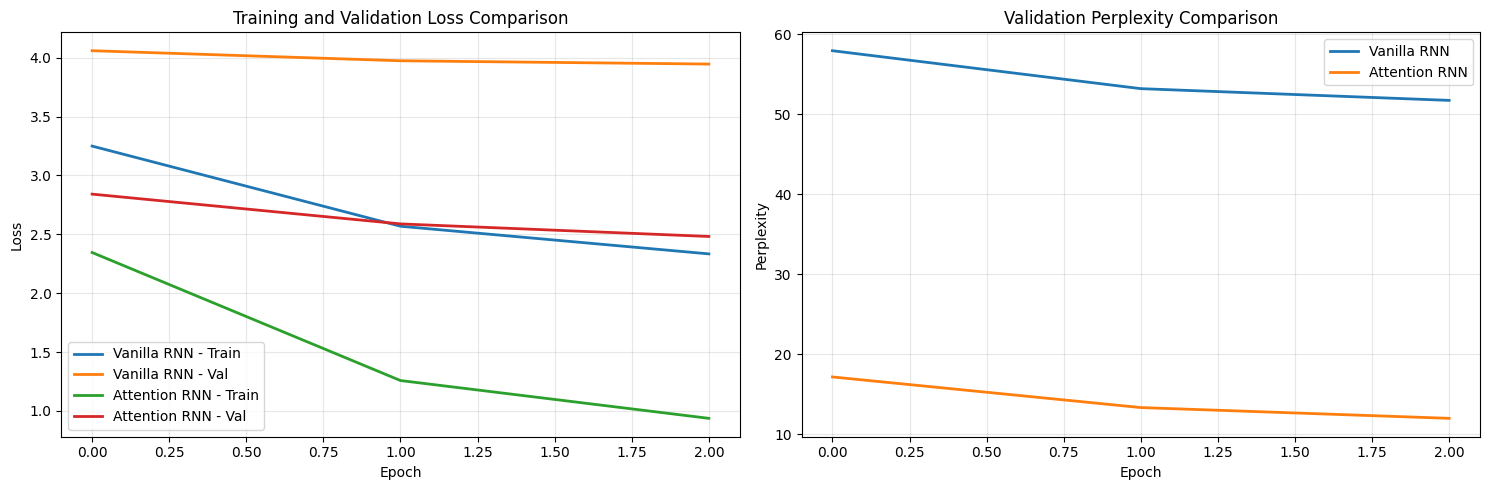


Final Performance Comparison:
----------------------------------------
Vanilla RNN - Final Val Loss: 3.9458 | Final Val PPL: 51.72
Attention RNN - Final Val Loss: 2.4818 | Final Val PPL: 11.96
Perplexity Improvement with Attention: 76.9%


In [18]:
# Cell 14: Plot training curves

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss comparison
axes[0].plot(vanilla_train_losses, label='Vanilla RNN - Train', linewidth=2)
axes[0].plot(vanilla_val_losses, label='Vanilla RNN - Val', linewidth=2)
axes[0].plot(attention_train_losses, label='Attention RNN - Train', linewidth=2)
axes[0].plot(attention_val_losses, label='Attention RNN - Val', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Perplexity comparison
vanilla_train_ppl = [calculate_perplexity(loss) for loss in vanilla_train_losses]
vanilla_val_ppl = [calculate_perplexity(loss) for loss in vanilla_val_losses]
attention_train_ppl = [calculate_perplexity(loss) for loss in attention_train_losses]
attention_val_ppl = [calculate_perplexity(loss) for loss in attention_val_losses]

axes[1].plot(vanilla_val_ppl, label='Vanilla RNN', linewidth=2)
axes[1].plot(attention_val_ppl, label='Attention RNN', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('Validation Perplexity Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final performance
print("\nFinal Performance Comparison:")
print("-" * 40)
print(f"Vanilla RNN - Final Val Loss: {vanilla_val_losses[-1]:.4f} | Final Val PPL: {vanilla_val_ppl[-1]:.2f}")
print(f"Attention RNN - Final Val Loss: {attention_val_losses[-1]:.4f} | Final Val PPL: {attention_val_ppl[-1]:.2f}")
improvement = ((vanilla_val_ppl[-1] - attention_val_ppl[-1]) / vanilla_val_ppl[-1]) * 100
print(f"Perplexity Improvement with Attention: {improvement:.1f}%")

In [25]:
# Cell 15: Translation examples and attention visualization

def translate_and_visualize(model, sentence, src_vocab, tgt_vocab, with_attention=False):
    """Translate a sentence and visualize attention if applicable"""

    # Encode source sentence
    src_encoded = torch.tensor([src_vocab.encode(sentence)]).to(device)

    if with_attention:
        # Get translation with attention weights
        translated_indices, attention_weights = model.translate(src_encoded)
        attention_weights = attention_weights.squeeze(1).cpu().numpy()
    else:
        # Get translation without attention
        translated_indices = model.translate(src_encoded)
        attention_weights = None

    # Decode translation
    translated = tgt_vocab.decode(translated_indices)

    return translated, attention_weights


In [26]:
# Cell 13.5: TEST SET EVALUATION - Final Model Performance

def evaluate_test_set(model, test_data, src_vocab, tgt_vocab, model_name, with_attention=False):
    """
    Comprehensive evaluation on test set
    Returns: dict with accuracy, BLEU, per-length performance, and sample translations
    """
    model.eval()
    
    results = {
        'model_name': model_name,
        'total': len(test_data),
        'correct': 0,
        'translations': [],
        'length_performance': {}
    }
    
    # Collect all predictions and references for BLEU
    all_predictions = []
    all_references = []
    
    print(f"\n{'=' * 70}")
    print(f"EVALUATING {model_name} ON TEST SET")
    print(f"{'=' * 70}")
    
    with torch.no_grad():
        for idx, (src, tgt) in enumerate(tqdm(test_data, desc=f"Testing {model_name}")):
            # Translate - translate_and_visualize already returns decoded string!
            predicted, _ = translate_and_visualize(
                model, src, src_vocab, tgt_vocab, with_attention=with_attention
            )
            
            # Store for BLEU calculation
            all_predictions.append(predicted)
            all_references.append(tgt)
            
            # Check exact match
            if predicted.strip() == tgt.strip():
                results['correct'] += 1
            
            # Track per-length accuracy
            src_len = len(src.split())
            if src_len not in results['length_performance']:
                results['length_performance'][src_len] = {'correct': 0, 'total': 0}
            results['length_performance'][src_len]['total'] += 1
            if predicted.strip() == tgt.strip():
                results['length_performance'][src_len]['correct'] += 1
            
            # Save first 10 translations as samples
            if idx < 10:
                results['translations'].append({
                    'source': src,
                    'predicted': predicted,
                    'reference': tgt,
                    'correct': predicted.strip() == tgt.strip()
                })
    
    # Calculate overall accuracy
    results['accuracy'] = results['correct'] / results['total']
    
    # Calculate BLEU score if available
    if bleu_available:
        bleu = BLEU()
        # sacrebleu expects list of predictions and list of list of references
        bleu_score = bleu.corpus_score(all_predictions, [all_references])
        results['bleu'] = bleu_score.score  # BLEU score (0-100)
    else:
        results['bleu'] = None
    
    return results

# Evaluate both models on test set
print("\n" + "=" * 70)
print("FINAL EVALUATION ON HELD-OUT TEST SET")
print("=" * 70)
print(f"Test set size: {len(test_data)} sentence pairs")
print(f"These sentences were NEVER seen during training!")
print("=" * 70)

vanilla_test_results = evaluate_test_set(
    vanilla_model, test_data, src_vocab, tgt_vocab, "Vanilla RNN", with_attention=False
)

attention_test_results = evaluate_test_set(
    attention_model, test_data, src_vocab, tgt_vocab, "Attention RNN", with_attention=True
)

# Display results
print("\n" + "=" * 70)
print("FINAL TEST SET RESULTS")
print("=" * 70)

print(f"\n{'Metric':<25} {'Vanilla RNN':>20} {'Attention RNN':>20}")
print("-" * 70)
print(f"{'Exact Match Accuracy':<25} {vanilla_test_results['accuracy']:>19.2%} {attention_test_results['accuracy']:>20.2%}")

if bleu_available:
    print(f"{'BLEU Score (0-100)':<25} {vanilla_test_results['bleu']:>20.2f} {attention_test_results['bleu']:>20.2f}")
    bleu_improvement = attention_test_results['bleu'] - vanilla_test_results['bleu']
    print(f"{'BLEU Improvement':<25} {bleu_improvement:>20.2f} points")

accuracy_improvement = (attention_test_results['accuracy'] - vanilla_test_results['accuracy']) * 100
print(f"{'Accuracy Improvement':<25} {accuracy_improvement:>20.2f} percentage points")

# Show per-length performance
print(f"\n{'=' * 70}")
print("PERFORMANCE BY SOURCE SENTENCE LENGTH")
print("=" * 70)
print(f"{'Length':<10} {'Vanilla Accuracy':>20} {'Attention Accuracy':>20} {'Improvement':>15}")
print("-" * 70)

all_lengths = sorted(set(vanilla_test_results['length_performance'].keys()) | 
                     set(attention_test_results['length_performance'].keys()))

for length in all_lengths:
    v_perf = vanilla_test_results['length_performance'].get(length, {'correct': 0, 'total': 0})
    a_perf = attention_test_results['length_performance'].get(length, {'correct': 0, 'total': 0})
    
    v_acc = v_perf['correct'] / v_perf['total'] if v_perf['total'] > 0 else 0
    a_acc = a_perf['correct'] / a_perf['total'] if a_perf['total'] > 0 else 0
    improvement = (a_acc - v_acc) * 100
    
    print(f"{length:<10} {v_acc:>19.1%} {a_acc:>20.1%} {improvement:>+14.1f}pp")

# Show sample translations
print(f"\n{'=' * 70}")
print("SAMPLE TRANSLATIONS FROM TEST SET")
print("=" * 70)

for i, (v_trans, a_trans) in enumerate(zip(vanilla_test_results['translations'][:5], 
                                             attention_test_results['translations'][:5])):
    print(f"\n{i+1}. Source (French):     {v_trans['source']}")
    print(f"   Reference (English):  {v_trans['reference']}")
    print(f"   Vanilla RNN:          {v_trans['predicted']} {'✓' if v_trans['correct'] else '✗'}")
    print(f"   Attention RNN:        {a_trans['predicted']} {'✓' if a_trans['correct'] else '✗'}")

print("\n" + "=" * 70)


FINAL EVALUATION ON HELD-OUT TEST SET
Test set size: 14276 sentence pairs
These sentences were NEVER seen during training!

EVALUATING Vanilla RNN ON TEST SET


Testing Vanilla RNN: 100%|██████████| 14276/14276 [00:39<00:00, 357.11it/s]
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.



EVALUATING Attention RNN ON TEST SET


Testing Attention RNN: 100%|██████████| 14276/14276 [01:01<00:00, 232.86it/s]
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.



FINAL TEST SET RESULTS

Metric                             Vanilla RNN        Attention RNN
----------------------------------------------------------------------
Exact Match Accuracy                    0.00%                2.42%
BLEU Score (0-100)                        2.70                23.82
BLEU Improvement                         21.12 points
Accuracy Improvement                      2.42 percentage points

PERFORMANCE BY SOURCE SENTENCE LENGTH
Length         Vanilla Accuracy   Attention Accuracy     Improvement
----------------------------------------------------------------------
3                         0.0%                 0.0%           +0.0pp
4                         0.0%                 0.0%           +0.0pp
5                         0.0%                 1.4%           +1.4pp
6                         0.0%                 2.7%           +2.7pp
7                         0.0%                 3.0%           +3.0pp
8                         0.0%                 2.5%       


Visualizing attention for: 'comment allez vous' (French)
Translation: 'how are you going to come back .' (English)


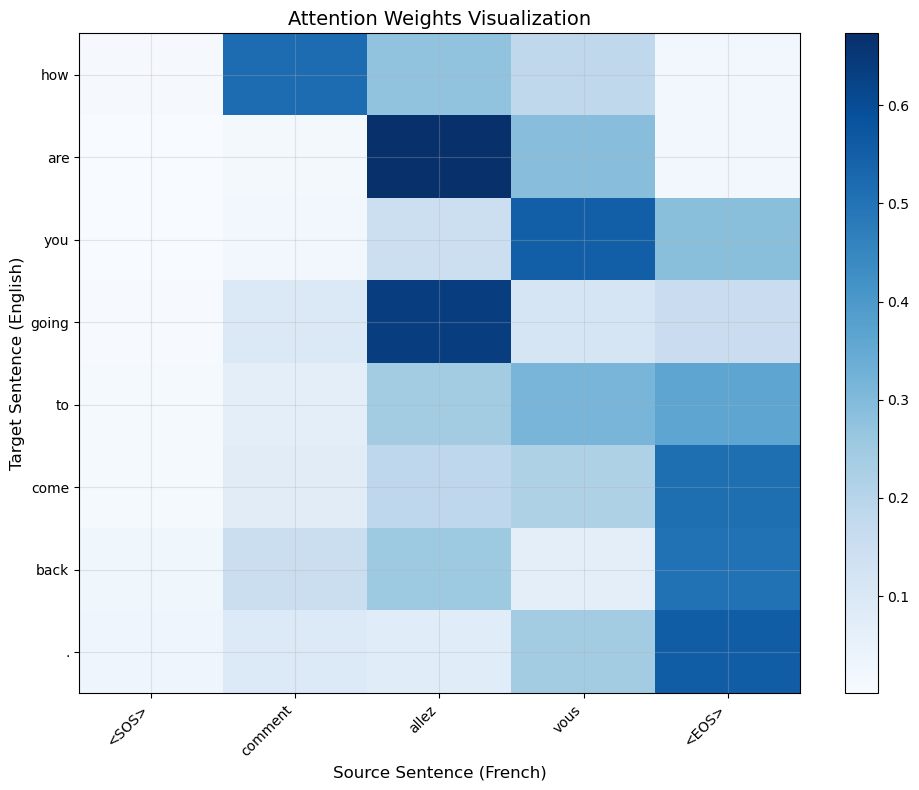


Visualizing attention for: 'ou est le marche' (French)
Translation: 'where is the market ?' (English)


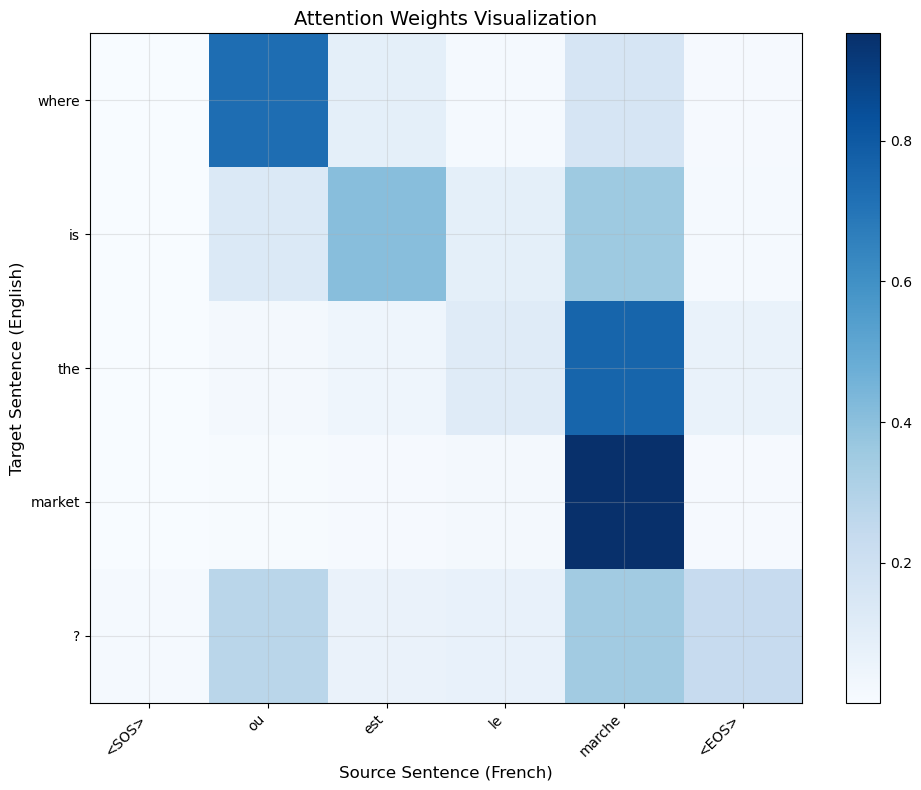

In [27]:
# Cell 16: Visualize attention weights

def plot_attention(sentence, translation, attention_weights, src_vocab):
    """Plot attention heatmap"""

    # Process source and target sentences
    src_tokens = ['<SOS>'] + sentence.split() + ['<EOS>']
    tgt_tokens = translation.split() if translation else ['<EOS>']

    # Adjust attention weights size
    attention_weights = attention_weights[:len(tgt_tokens), :len(src_tokens)]

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot heatmap
    im = ax.imshow(attention_weights, cmap='Blues', aspect='auto')

    # Set ticks and labels
    ax.set_xticks(range(len(src_tokens)))
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha='right')
    ax.set_yticklabels(tgt_tokens)

    # Labels
    ax.set_xlabel('Source Sentence (French)', fontsize=12)
    ax.set_ylabel('Target Sentence (English)', fontsize=12)
    ax.set_title('Attention Weights Visualization', fontsize=14)

    # Add colorbar
    plt.colorbar(im, ax=ax)

    # Add grid
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Visualize attention for selected sentences (MUST BE FRENCH)
sentences_to_visualize = ["comment allez vous", "ou est le marche"]

for sentence in sentences_to_visualize:
    print(f"\nVisualizing attention for: '{sentence}' (French)")

    # Get translation with attention
    attention_translation, attention_weights = translate_and_visualize(
        attention_model, sentence, src_vocab, tgt_vocab, with_attention=True
    )
    
    print(f"Translation: '{attention_translation}' (English)")

    # Plot attention
    if attention_weights is not None:
        plot_attention(sentence, attention_translation, attention_weights, src_vocab)

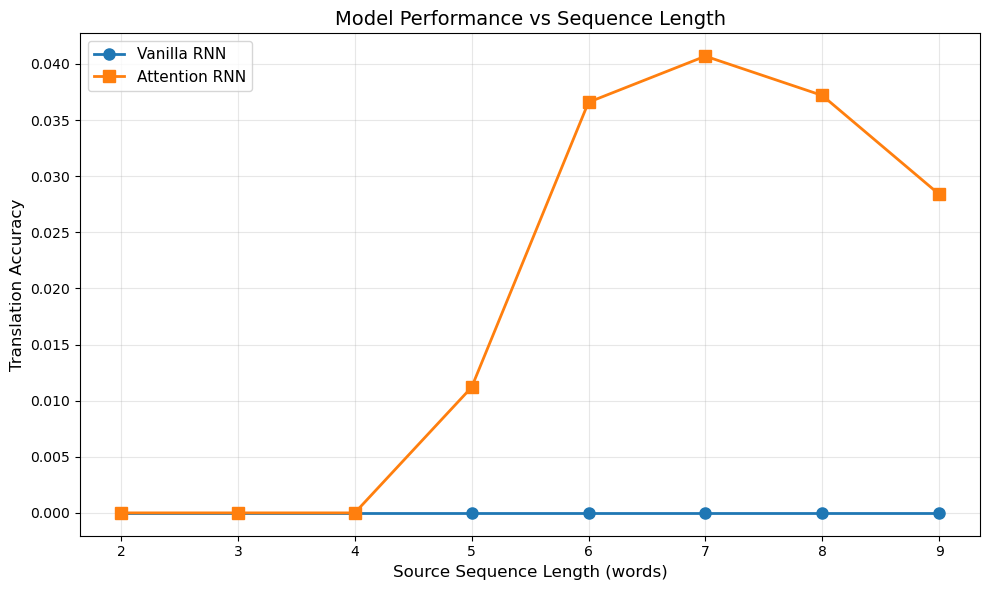


Performance by Sequence Length:
----------------------------------------
Length 2: Vanilla=0.00%, Attention=0.00%
Length 3: Vanilla=0.00%, Attention=0.00%
Length 4: Vanilla=0.00%, Attention=0.00%
Length 5: Vanilla=0.00%, Attention=1.12%
Length 6: Vanilla=0.00%, Attention=3.66%
Length 7: Vanilla=0.00%, Attention=4.07%
Length 8: Vanilla=0.00%, Attention=3.72%
Length 9: Vanilla=0.00%, Attention=2.84%


In [28]:
# Cell 17: Analyze model behavior with sequence length

def analyze_sequence_length_performance(vanilla_model, attention_model, val_data, src_vocab, tgt_vocab):
    """Analyze how models perform with different sequence lengths"""

    # Group validation data by source sequence length
    length_groups = {}
    for src, tgt in val_data:
        src_len = len(src.split())
        if src_len not in length_groups:
            length_groups[src_len] = []
        length_groups[src_len].append((src, tgt))

    # Calculate accuracy for each length group
    vanilla_accuracies = {}
    attention_accuracies = {}

    for length, sentences in length_groups.items():
        vanilla_correct = 0
        attention_correct = 0

        for src, tgt_true in sentences:
            # Vanilla RNN
            vanilla_trans, _ = translate_and_visualize(vanilla_model, src, src_vocab, tgt_vocab, with_attention=False)
            if vanilla_trans.strip() == tgt_true.strip():
                vanilla_correct += 1

            # Attention RNN
            attention_trans, _ = translate_and_visualize(attention_model, src, src_vocab, tgt_vocab, with_attention=True)
            if attention_trans.strip() == tgt_true.strip():
                attention_correct += 1

        if sentences:
            vanilla_accuracies[length] = vanilla_correct / len(sentences)
            attention_accuracies[length] = attention_correct / len(sentences)

    return vanilla_accuracies, attention_accuracies

# Analyze performance
vanilla_acc, attention_acc = analyze_sequence_length_performance(
    vanilla_model, attention_model, val_data, src_vocab, tgt_vocab
)

# Plot results
lengths = sorted(vanilla_acc.keys())
vanilla_scores = [vanilla_acc[l] for l in lengths]
attention_scores = [attention_acc[l] for l in lengths]

plt.figure(figsize=(10, 6))
plt.plot(lengths, vanilla_scores, 'o-', label='Vanilla RNN', linewidth=2, markersize=8)
plt.plot(lengths, attention_scores, 's-', label='Attention RNN', linewidth=2, markersize=8)
plt.xlabel('Source Sequence Length (words)', fontsize=12)
plt.ylabel('Translation Accuracy', fontsize=12)
plt.title('Model Performance vs Sequence Length', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print detailed comparison
print("\nPerformance by Sequence Length:")
print("-" * 40)
for length in lengths:
    print(f"Length {length}: Vanilla={vanilla_acc[length]:.2%}, Attention={attention_acc[length]:.2%}")